<a href="https://colab.research.google.com/github/khushi-narang/ml/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# MNIST Dataset
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

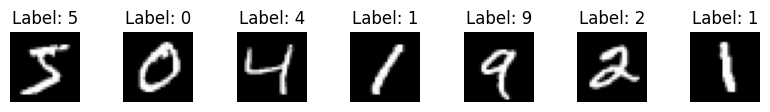

In [ ]:
def display_sample_images(images, labels, num_images):
    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        plt.subplot(2, num_images, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.show()
display_sample_images(X_train, y_train,7)

In [ ]:
# One-hot encoding

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

NameError: name 'to_categorical' is not defined

In [ ]:
# Simple feed forward neural network

model = Sequential(
    [
        Flatten(input_shape=(28, 28)),  #input layer
        # Dence(nodes, activation function)
        Dense(256, activation='relu'),  #adding another hidden layer
        Dropout(0.3), #prevent overfitting
        Dense(128, activation='relu'),  #hidden
        Dropout(0.3),
        Dense(64, activation='relu'),   #hidden
        Dropout(0.3),
        Dense(10, activation='softmax') #output layer
    ]
)

In [ ]:
#compile the model
model.compile(optimizer= 'adam', loss='categorical_crossentropy', metrics=['accuracy'])

#train the model and save training history
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7969 - loss: 0.6414 - val_accuracy: 0.9580 - val_loss: 0.1332
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9450 - loss: 0.1955 - val_accuracy: 0.9703 - val_loss: 0.0993
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9582 - loss: 0.1487 - val_accuracy: 0.9726 - val_loss: 0.0935
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9654 - loss: 0.1248 - val_accuracy: 0.9738 - val_loss: 0.0910
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9694 - loss: 0.1049 - val_accuracy: 0.9756 - val_loss: 0.0805
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9718 - loss: 0.0970 - val_accuracy: 0.9785 - val_loss: 0.0766
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9732 - loss: 0.0926 - val_accuracy: 0.9782 - val_loss: 0.0766
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9766 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9784 - loss: 0.0865
Test loss: 0.07258344441652298
Test accuracy: 0.9811999797821045


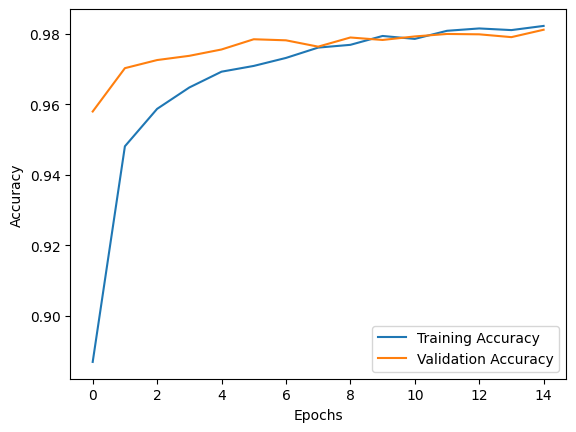

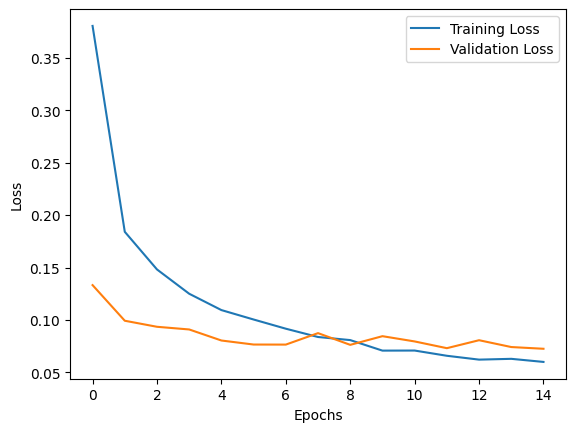

In [ ]:
# Evaluate the model

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_acc}')

# Visualize the training process

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()